[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1pOs_uSvwNLOBRsNZHvgYVcWKrvemf3yB)

# Data

We'll be using the newly released dataset to model authorship of Victorian Era literature.

http://archive.ics.uci.edu/ml/datasets/Victorian+Era+Authorship+Attribution

We will use this dataset to classify authors based on their writings.

Download links available at – https://dataworks.iupui.edu/handle/11243/23

In [1]:
import pandas as pd

df = pd.read_csv('https://dataworks.iupui.edu/bitstream/handle/11243/23/Gungor_2018_VictorianAuthorAttribution_data-train.csv?sequence=2&isAllowed=y', encoding='ISO-8859-1')
df.head()

,text,author
0,ou have time to listen i will give you the ent...,1
1,wish for solitude he was twenty years of age a...,1
2,and the skirt blew in perfect freedom about th...,1
3,of san and the rows of shops opposite impresse...,1
4,an hour s walk was as tiresome as three in a s...,1


In [0]:
seed = 42

In [3]:
df.shape

(53678, 2)

Dataset is huge – Let's sample a subset for iterating (once we finalize our model, we can run the model on the entire dataset)

In [4]:
data = df.sample(frac=0.1)
data.shape

(5368, 2)

In [5]:
texts = data['text'].tolist()
texts[0:5]

['don t go â please don t go she rested her hand on mine and sent my pulse fluttering my heart was surely in my eyes for a moment the dear and lovely woman and she was so much the woman clinging and appealing sunshine and dew to my manhood it deeper and sending through it the sap of a new strength i was for putting my arm around her as when in the midst of the seal herd but i considered and refrained i shall not take any risks i said i ll merely peep over the bow and see she pressed my hand earnestly and let me go but the space on deck where i had left him lying was vacant he had evidently gone below that night we stood alternate watches one of us sleeping at a time for there was the sea wolf no telling what wolf might do he was certainly capable of anything the next day we waited and the next and still he made no sign these of his these attacks said on the afternoon of the fourth day perhaps he is ill very ill he may be dead or dying was her when she had waited some time for me to spe

# TensorFlow Hub & Transfer Learning

"A library for reusable machine learning modules"

> This lets you quickly take advantage of a model that was trained with thousands of GPU hours. It also enables transfer learning - reusing a part of a trained model (called a module) that includes weights and assets, but also training the overall model some yourself with your own data. The advantages are fairly clear - you can use less training data, have faster training, and have a model that generalizes better.

https://www.tensorflow.org/hub/

---

### Use pre-trained embeddings, trained on English Google News 200B corpus

https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1

In [6]:
import tensorflow as tf
import tensorflow_hub as hub

with tf.Graph().as_default():
  module_url = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1"
  embed = hub.Module(module_url)
  embeddings = embed(texts)

  with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    sess.run(tf.tables_initializer())

    print(sess.run(embeddings))
    X = embeddings.eval()

INFO:tensorflow:Using /tmp/tfhub_modules to cache modules.
INFO:tensorflow:Downloading TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1'.
INFO:tensorflow:Downloaded TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1'.
INFO:tensorflow:Saver not created because there are no variables in the graph to restore
[[ 4.193631    0.26585183  0.74276435 ... -1.0191239  -0.06995381
   0.0241245 ]
 [ 4.747674    0.1908183   0.67888784 ... -0.58829033  0.12891382
  -0.09896024]
 [ 4.52947    -0.01768246  0.58569026 ... -0.74547833  0.43733096
  -0.0108403 ]
 ...
 [ 4.4146256  -0.00907896  0.623606   ... -1.1231045  -0.09455542
  -0.05647869]
 [ 4.6613064   0.18975252  0.6973236  ... -0.6018348  -0.02001836
   0.03118367]
 [ 4.7573423   0.07764363  0.6241165  ... -0.88032335  0.05959882
   0.30986848]]


In [7]:
X.shape

(5368, 128)

In [8]:
embedding_dimensions = X.shape[1]
print('Dimension of Embeddings:', embedding_dimensions)

Dimension of Embeddings: 128


# Baseline Model

In [9]:
authors = data['author'].tolist()
print(authors)

[21, 19, 15, 10, 37, 25, 26, 35, 32, 39, 35, 44, 15, 21, 8, 8, 48, 41, 8, 45, 8, 8, 9, 6, 28, 30, 16, 39, 45, 41, 36, 12, 46, 45, 38, 1, 23, 30, 17, 50, 37, 10, 32, 8, 39, 21, 36, 10, 42, 8, 19, 26, 26, 32, 8, 6, 19, 15, 39, 8, 19, 19, 33, 26, 24, 8, 19, 25, 8, 15, 8, 33, 10, 45, 38, 15, 1, 44, 26, 41, 12, 6, 42, 19, 26, 28, 37, 43, 15, 48, 8, 43, 26, 36, 15, 37, 13, 17, 14, 24, 36, 19, 18, 26, 30, 14, 15, 37, 33, 33, 19, 8, 21, 8, 45, 40, 14, 12, 22, 2, 13, 41, 8, 14, 8, 14, 20, 26, 8, 32, 42, 8, 8, 45, 10, 40, 24, 35, 25, 20, 14, 34, 45, 22, 14, 8, 26, 33, 19, 21, 4, 26, 8, 35, 26, 26, 30, 4, 8, 27, 15, 36, 26, 8, 37, 26, 20, 39, 25, 21, 15, 8, 25, 26, 13, 8, 26, 40, 35, 12, 21, 39, 13, 14, 26, 8, 21, 12, 19, 37, 41, 8, 8, 43, 20, 8, 21, 21, 15, 45, 21, 18, 14, 38, 15, 8, 39, 8, 26, 1, 19, 19, 29, 8, 8, 8, 45, 50, 26, 8, 13, 42, 25, 41, 12, 45, 36, 14, 50, 26, 8, 37, 43, 8, 19, 25, 8, 19, 18, 4, 21, 26, 17, 37, 48, 26, 36, 37, 15, 38, 35, 26, 45, 42, 30, 10, 8, 41, 10, 4, 25, 42, 8, 

In [10]:
num_classes = max(authors) + 1
print('Number of unique labels:', num_classes)

Number of unique labels: 51


Make "one-hot" encodings from labels

In [11]:
from keras.utils import to_categorical

y = to_categorical(authors, num_classes)
print(y.shape)
y

(5368, 51)


Using TensorFlow backend.


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [0]:
x_train, y_train = X, y

In [15]:
print('Train:', x_train.shape, y_train.shape)

Train: (5368, 128) (5368, 51)


In [19]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(embedding_dimensions, input_dim=embedding_dimensions, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_4 (Dense)              (None, 51)                6579      
Total params: 23,091
Trainable params: 23,091
Non-trainable params: 0
_________________________________________________________________
None


In [20]:
fitted_model = model.fit(x_train, y_train, validation_split=0.2, epochs=10, batch_size=32, verbose=2)

Train on 4294 samples, validate on 1074 samples
Epoch 1/10
 - 0s - loss: 3.2759 - acc: 0.2059 - val_loss: 2.9151 - val_acc: 0.2840
Epoch 2/10
 - 0s - loss: 2.7573 - acc: 0.2913 - val_loss: 2.5584 - val_acc: 0.3436
Epoch 3/10
 - 0s - loss: 2.4530 - acc: 0.3482 - val_loss: 2.3432 - val_acc: 0.3855
Epoch 4/10
 - 0s - loss: 2.2389 - acc: 0.4108 - val_loss: 2.1927 - val_acc: 0.4227
Epoch 5/10
 - 0s - loss: 2.0605 - acc: 0.4495 - val_loss: 2.0719 - val_acc: 0.4488
Epoch 6/10
 - 0s - loss: 1.9206 - acc: 0.4844 - val_loss: 1.9313 - val_acc: 0.5000
Epoch 7/10
 - 0s - loss: 1.7982 - acc: 0.5256 - val_loss: 1.8382 - val_acc: 0.5214
Epoch 8/10
 - 0s - loss: 1.6978 - acc: 0.5482 - val_loss: 1.7698 - val_acc: 0.5186
Epoch 9/10
 - 0s - loss: 1.6086 - acc: 0.5734 - val_loss: 1.6947 - val_acc: 0.5447
Epoch 10/10
 - 0s - loss: 1.5392 - acc: 0.5880 - val_loss: 1.6385 - val_acc: 0.5512


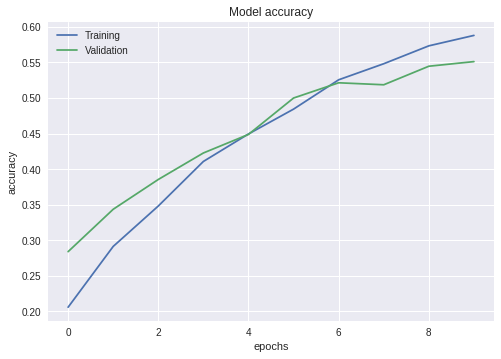

In [21]:
import matplotlib.pyplot as plt

plt.plot(fitted_model.history['acc'], label="Training")
plt.plot(fitted_model.history['val_acc'], label="Validation")
plt.title("Model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show();

**Observation:** Both the training and the validation accuracy seems to be increasing with more epochs => hints we should probably try a higher number of epochs

# K-fold Cross Validation

Instead of just setting a part of our training set aside for Cross Validation, let's use K-fold CV for better validating and understanding of how the baseline might be doing

In [0]:
def create_model():
  model = Sequential()
  model.add(Dense(embedding_dimensions, input_dim=embedding_dimensions, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))

  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [0]:
from keras.wrappers.scikit_learn import KerasClassifier

estimator = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, verbose=2)

In [0]:
CV_FOLDS = 3

In [36]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
scores = cross_val_score(estimator, x_train, y_train, cv=kfold)
print("Scores:", scores)
print("Accuracy: %.2f%%" % (scores.mean()*100))

Epoch 1/10
 - 0s - loss: 3.2860 - acc: 0.1937
Epoch 2/10
 - 0s - loss: 2.8065 - acc: 0.3010
Epoch 3/10
 - 0s - loss: 2.5411 - acc: 0.3385
Epoch 4/10
 - 0s - loss: 2.3377 - acc: 0.3798
Epoch 5/10
 - 0s - loss: 2.1623 - acc: 0.4212
Epoch 6/10
 - 0s - loss: 2.0274 - acc: 0.4516
Epoch 7/10
 - 0s - loss: 1.9091 - acc: 0.4933
Epoch 8/10
 - 0s - loss: 1.8184 - acc: 0.5092
Epoch 9/10
 - 0s - loss: 1.7189 - acc: 0.5419
Epoch 10/10
 - 0s - loss: 1.6376 - acc: 0.5668
Epoch 1/10
 - 0s - loss: 3.3282 - acc: 0.1841
Epoch 2/10
 - 0s - loss: 2.8385 - acc: 0.2814
Epoch 3/10
 - 0s - loss: 2.5455 - acc: 0.3277
Epoch 4/10
 - 0s - loss: 2.3344 - acc: 0.3820
Epoch 5/10
 - 0s - loss: 2.1636 - acc: 0.4283
Epoch 6/10
 - 0s - loss: 2.0291 - acc: 0.4669
Epoch 7/10
 - 0s - loss: 1.9105 - acc: 0.4937
Epoch 8/10
 - 0s - loss: 1.8110 - acc: 0.5197
Epoch 9/10
 - 0s - loss: 1.7263 - acc: 0.5446
Epoch 10/10
 - 0s - loss: 1.6462 - acc: 0.5694
Epoch 1/10
 - 1s - loss: 3.3117 - acc: 0.1967
Epoch 2/10
 - 0s - loss: 2.8491 

# Hyperparameter Tuning

using GridSearchCV

In [0]:
from keras.layers import Dropout

def create_model(num_neurons, dropout):
  model = Sequential()
  model.add(Dense(num_neurons, input_dim=embedding_dimensions, activation='relu'))
  if dropout > 0.0:
    model.add(Dropout(dropout))  
  model.add(Dense(num_classes, activation='softmax'))
  
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])  
  return model

In [38]:
batch_size = [32]
epochs = [5, 10, 50, 100]
num_neurons = [embedding_dimensions, embedding_dimensions*2, embedding_dimensions*4]
dropout = [0.0, 0.5]

hyperparam_grid = dict(batch_size=batch_size, 
                       epochs=epochs, 
                       num_neurons=num_neurons, 
                       dropout=dropout)

hyperparam_grid

{'batch_size': [32],
 'dropout': [0.0, 0.5],
 'epochs': [5, 10, 50, 100],
 'num_neurons': [128, 256, 512]}

In [0]:
estimator = KerasClassifier(build_fn=create_model, verbose=2)

In [0]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=estimator, param_grid=hyperparam_grid, cv=CV_FOLDS, verbose=2)
grid_result = grid_search.fit(x_train, y_train)

In [41]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, std, param in zip(means, stds, params):
  print("%f (%f) with: %r" % (mean, std, param))

Best: 0.741431 using {'batch_size': 32, 'dropout': 0.5, 'epochs': 100, 'num_neurons': 512}
0.427347 (0.005804) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 128}
0.468331 (0.009377) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 256}
0.529806 (0.008720) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 512}
0.559613 (0.012136) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 128}
0.584016 (0.019887) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 256}
0.607303 (0.018620) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 512}
0.691878 (0.013323) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 128}
0.704918 (0.016377) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 256}
0.721125 (0.013938) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 512}
0.706222 (0.007008) with: {'batch_size': 32, 'dropout': 0

**Best: 0.741431 using {'batch_size': 32, 'dropout': 0.5, 'epochs': 100, 'num_neurons': 512}**

# Final model

Let's discard the sample set and use the entire set now

In [42]:
data = df.copy()
data.shape

(53678, 2)

In [43]:
texts = data['text'].tolist()
texts[0:5]

['ou have time to listen i will give you the entire story he said it may form the basis of a future novel and prove quite as interesting as one of your own invention i had the time to listen of course one has time for anything and everything agreeable in the best place to hear the tale was in a victoria and with my good on the box with the coachman we set out at once on a drive to the as the recital was only half through when we reached the house we postponed the remainder while we stopped there for an excellent lunch on the way back to my friend continued and finished the story it was indeed quite suitable for use and i told my friend with thanks that i should at once put it in shape for my readers i said i should make a few alterations in it for the sake of dramatic interest but in the main would follow the lines he had given me it would spoil my romance were i to answer on this page the question that must be uppermost in the reader s mind i have already revealed almost too much of t

In [44]:
with tf.Graph().as_default():
  module_url = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1"
  embed = hub.Module(module_url)
  embeddings = embed(texts)

  with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    sess.run(tf.tables_initializer())

    print(sess.run(embeddings))
    X = embeddings.eval()

INFO:tensorflow:Saver not created because there are no variables in the graph to restore
[[ 4.742724   -0.03984392  0.4347267  ... -1.381325    0.4436839
   0.3926557 ]
 [ 4.638058    0.11435992  0.5076428  ... -1.3490543   0.14249295
   0.08708809]
 [ 4.657072    0.05044416  0.31282306 ... -1.3132746  -0.16678776
  -0.00755485]
 ...
 [ 4.2718134  -0.01576476  0.70100456 ... -0.91154325 -0.24903299
   0.06295525]
 [ 4.3038507  -0.05889306  0.7539825  ... -0.9108152  -0.09493008
  -0.0821903 ]
 [ 4.27195    -0.13434537  0.54746425 ... -0.95999247 -0.05214985
   0.01255544]]


In [45]:
X.shape

(53678, 128)

In [46]:
embedding_dimensions = X.shape[1]
print('Dimension of Embeddings:', embedding_dimensions)

Dimension of Embeddings: 128


In [0]:
authors = data['author'].tolist()

In [48]:
num_classes = max(authors) + 1
print('Number of unique labels:', num_classes)
y = to_categorical(authors, num_classes)
print(y.shape)

Number of unique labels: 51
(53678, 51)


Let's keep a Test set aside, for the final evaluation of how our model is doing on completely **unseen** data

In [0]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [50]:
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (42942, 128) (42942, 51)
Test: (10736, 128) (10736, 51)


Best: 0.741431 using {'batch_size': 32, 'dropout': 0.5, 'epochs': 100, 'num_neurons': 512}

In [0]:
def create_model():
  model = Sequential()
  model.add(Dense(512, input_dim=embedding_dimensions, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(num_classes, activation='softmax'))

  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [0]:
estimator = KerasClassifier(build_fn=create_model, epochs=100, batch_size=32, verbose=2)
kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
scores = cross_val_score(estimator, x_train, y_train, cv=kfold)

In [54]:
print("Scores:", scores)
print("Accuracy: %.2f%%" % (scores.mean()*100))

Scores: [0.84448791 0.85119463 0.85601509]
Accuracy: 85.06%


**Observation:** Out best (tuned) model is generating an Accuracy score of 85.06% with 3-fold Cross Validation, when evaludated on a 80-20 split Training set. (seed=42)

### Final training and evaluation

Let's train the finalized model on the entire Training set, and see what accuracy we get on the **Test set** we had set aside.

In [0]:
model = Sequential()
model.add(Dense(512, input_dim=embedding_dimensions, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
fitted_model = model.fit(x_train, y_train, epochs=100, batch_size=32, verbose=2)

In [56]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print('Accuracy: %.2f%%' % (accuracy * 100))

Accuracy: 86.19%


**Observation:** Pretty close to the Cross Validation accuracy, which is good. 

Note: judging the model's performance only from the Cross Validation accuracy might not be sufficient, as remember we did tune our hyperparameters using a Cross Validation approach – so there is a slight chance that we can end up **overfitting** our hyperparameters on the cross validation sets we generated (though we did use shuffle=True while evaluating Cross Validation accuracy later on). 

Regardless it is always a good practice to keep 1 set aside for the final testing, which the training process (including hyperparameter tuning) never sees.

In this particular case, it looks like our model has generalized pretty well. 

(Also note that we did do our hyperparameter tuning using a sample of the entire set – which doesn't necessarily represent the best hyperparameters for the entire set – but this was done for demonstration purposes in an environment limited to time and computing power).